# Fig. S1 barcode validation and sequencing quality control

Run `0a_barcode_sorting.ipynb` first. Generates the saved panels for Fig. S1A-J.


In [2]:
import sys; sys.path.append('..') ## proejct root
from methods.config import *
import methods.shared as shared
import methods.plot_utils as plot_utils
import pickle
import numpy as np
import numpy.random as rnd
import matplotlib.pyplot as plt

plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 10

with open(f'{pickled_dir}/barcode_pool_assignments.pkl', 'rb') as f:
    barcode_pool_assignments = pickle.load(f)
with open(f'{pickled_dir}/barcode_index_hopping_rates.pkl', 'rb') as f:
    barcode_hopping_rates = pickle.load(f)
with open(f'{pickled_dir}/barcode_hopping_inference_data.pkl', 'rb') as f:
    hopping_inference_data = pickle.load(f)
with open(f'{pickled_dir}/barcode_sorting_plot_data.pkl', 'rb') as f:
    barcode_sorting_plot_data = pickle.load(f)

P1_uncombined_sorted = barcode_sorting_plot_data['P1_uncombined_sorted']
P2_uncombined_sorted = barcode_sorting_plot_data['P2_uncombined_sorted']
sorting = barcode_sorting_plot_data['sorting']
unsorted_reseq_freqs = barcode_sorting_plot_data['unsorted_reseq_freqs']

vivo_array, vivo_depths = shared.vivo_array, shared.vivo_depths
vitro_array, vitro_depths = shared.vitro_array, shared.vitro_depths
reseq_array, reseq_depths = shared.reseq_array, shared.reseq_depths
og_seq_array = np.array(list(vivo_array) + list(vitro_array))
og_seq_depths = np.array(list(vivo_depths) + list(vitro_depths))
col_id_map = shared.col_id_map
barcode_arrays = {
    'vivo': (vivo_array, vivo_depths),
    'vitro': (vitro_array, vitro_depths),
    'reseq': (reseq_array, reseq_depths),
}


## Fig. S1A-D: pool composition, colonization, and reproducibility


34117 34845 45
MEDIAN MAPPING FRAC OVER ALL LIBRARIES (DEPTH = COVERAGE/SITE > 10): 0.9769605496421397


/var/folders/x3/8f6xdlhn4hscmskkzs52dycc0000gn/T/ipykernel_12242/3354674196.py:45: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax2.set_ylim(0, 1.05)


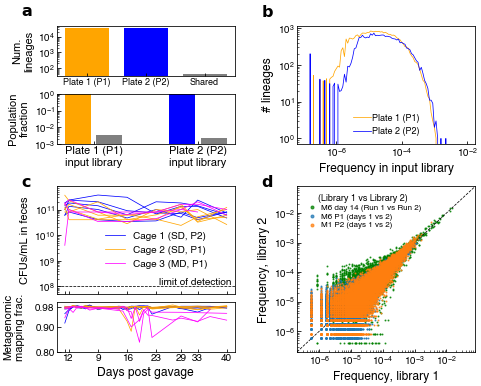

In [3]:
P1_index, P2_index = shared.library_array_map[('E1', 'P1')][0][1], shared.library_array_map[('E1', 'P2')][0][1]
P1_array, P1_depth = shared.vivo_array[P1_index], shared.vivo_depths[P1_index]
P2_array, P2_depth = shared.vivo_array[P2_index], shared.vivo_depths[P2_index]
P1_freqs = shared.calc_freqs(P1_array, P1_depth[0])
P2_freqs = shared.calc_freqs(P2_array, P2_depth[0])

P1_bool, P2_bool, ambiguous_bool = [shared.barcode_pool_assignments[pool][1] for pool in ['P1', 'P2', 'E1_shared']]
print(P1_bool.sum(), P2_bool.sum(), ambiguous_bool.sum())

### Plot technical replicates ~ Fig S1 ###
main_fig = plt.figure(figsize=(7.5, 6))
gs = plt.GridSpec(2, 2, figure=main_fig, wspace=0.35, hspace=0.3, height_ratios=[1,1.4])

#####################################################
## panel A: barcode pool assignments to Plate 1, 2 ##
#####################################################

inner_grid = gs[0, 0].subgridspec(2, 1, hspace=0.35)
ax = main_fig.add_subplot(inner_grid[0])
ax2 = main_fig.add_subplot(inner_grid[1])
ax.text(-0.2, 1.2, '$\\bf{a}$', fontsize=16, transform=ax.transAxes)


x1_lst = [0, 1, 2]
y1_lst = [P1_bool.sum(), P2_bool.sum(), ambiguous_bool.sum()]
colors = ['Orange', 'Blue', 'Grey']
for x, y, color in zip(x1_lst, y1_lst, colors):
    ax.bar(x, y, facecolor=color, width=0.75)
ax.set_xticks([0, 1, 2])
ax.set_yscale('log')
# ax.set_ylim(ax.get_ylim()[0], 31000)
# ax.set_yticks([0, 10000, 20000, 30000])
# ax.set_yticklabels([0, '$10^4$', '$2 \cdot 10^4$', '$3 \cdot 10^4$'], fontsize=10)
ax.set_xticklabels(['Plate 1 (P1)', 'Plate 2 (P2)', 'Shared'], fontsize=9)
ax.set_ylabel('Num.\nlineages', fontsize=11)

x2_lst = [-0.15, 0.15, 0.85, 1.15]
y2_lst = [P1_freqs[P1_bool].sum(), P1_freqs[ambiguous_bool].sum(),
          P2_freqs[P2_bool].sum(), P2_freqs[ambiguous_bool].sum()]
colors = ['Orange', 'Grey', 'Blue', 'Grey']
hatches = [None, None, None, None]
for x, y, color, hatch in zip(x2_lst, y2_lst, colors, hatches):
    ax2.bar(x, y, facecolor=color, width=0.25, hatch=hatch)
ax2.set_yscale('log'); ax2.set_ylim(1e-3, 2)
ax2.set_ylim(0, 1.05)
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Plate 1 (P1)\ninput library', 'Plate 2 (P2)\ninput library'], fontsize=11)
ax2.set_ylabel('Population\nfraction', fontsize=11)



#####################################################
## panel B: sequencing replicability ###
#####################################################

ax = main_fig.add_subplot(gs[0, 1])
ax.text(-0.2, 1.08, '$\\bf{b}$', fontsize=16, transform=ax.transAxes)


# ax.scatter(P1_rep1_freqs, P1_rep2_freqs, s=1, color='orange', rasterized=True, label="Plate 1 (P1)")
# ax.scatter(P2_rep1_freqs, P2_rep2_freqs, s=1, color='blue', rasterized=True, alpha=0.5, label="Plate 2 (P2)")
P1_density, bins = np.histogram( P1_freqs, bins=np.logspace(-7, -2, 101) )
ax.plot(bins[1:], P1_density, color='orange', alpha=1, label='Plate 1 (P1)')
P2_density, bins = np.histogram( P2_freqs, bins=np.logspace(-7, -2, 101) )
ax.plot(bins[1:], P2_density, color='blue', alpha=1, label='Plate 2 (P2)')

ax.legend(frameon=False, fontsize=9, markerscale=4, handletextpad=0.1)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Frequency in input library', fontsize=12)
# ax.set_ylabel('Rep 2 frequency', fontsize=12)
ax.set_ylabel('# lineages', fontsize=12)
# plot_utils.plot_diagonal(ax)

#####################################################
## panel D: within mouse day-to-day reproducibility ##
#####################################################
ax = main_fig.add_subplot(gs[1, 1])
ax.text(-0.2, 1.0, '$\\bf{d}$', fontsize=16, transform=ax.transAxes)
expt = 'E1'


# ('E1', 1, 3) [('vivo', 27), ('reseq', 0)]
rep2, rep1= shared.library_array_map[(expt, 6, 14)]
rep1_arr = shared.barcode_arrays[rep1[0]][0][rep1[1]]
rep1_depths = shared.barcode_arrays[rep1[0]][1][rep1[1]]
rep2_arr = shared.barcode_arrays[rep2[0]][0][rep2[1]]
rep2_depths = shared.barcode_arrays[rep2[0]][1][rep2[1]]

f1 = shared.calc_freqs(rep1_arr, rep1_depths[0])
f2 = shared.calc_freqs(rep2_arr, rep2_depths[0])
ax.scatter(f1, f2, s=1, rasterized=True, color='green', label=f'M{6} day 14 (Run 1 vs Run 2)', zorder=0, alpha=0.75)



for z, (mouse, color) in enumerate(zip([6, 1], ['blue', 'orange'])):
    rep1 = shared.library_array_map[(expt, mouse, 1)][0]
    rep2 = shared.library_array_map[(expt, mouse, 2)][0]

    rep1_arr = shared.barcode_arrays[rep1[0]][0][rep1[1]]
    rep1_depths = shared.barcode_arrays[rep1[0]][1][rep1[1]]
    rep2_arr = shared.barcode_arrays[rep2[0]][0][rep2[1]]
    rep2_depths = shared.barcode_arrays[rep2[0]][1][rep2[1]]

    f1 = shared.calc_freqs(rep1_arr, rep1_depths[0])
    f2 = shared.calc_freqs(rep2_arr, rep2_depths[0])
    ax.scatter(f1, f2, s=1, rasterized=True, label=f'M{mouse} P{z+1} (days 1 vs 2)', alpha=0.75)
    # day1_row = shared.vivo_row_ids[(expt, rep_mouse, 1)]
    # day2_row = shared.vivo_row_ids[(expt, rep_mouse, 2)]
    # f1 = shared.freq_array[day1_row]
    # f2 = shared.freq_array[day2_row]



ax.set_xlim(2*10**-7,8*10**-2)
ax.set_ylim(2*10**-7,8*10**-2)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Frequency, library 1', fontsize=12)
ax.set_ylabel('Frequency, library 2', fontsize=12)
plot_utils.plot_diagonal(ax)
ax.legend(title='(Library 1 vs Library 2)', title_fontsize=9, loc=2, frameon=False, fontsize=8, markerscale=3, handletextpad=0.05, labelspacing=0.15)

#####################################################
## panel C: CFUs/mL over time ##
#####################################################
panel_c_subgs = gs[1, 0].subgridspec(3,1, hspace=0.15)
ax = main_fig.add_subplot(panel_c_subgs[:2, 0])
mgx_ax = main_fig.add_subplot(panel_c_subgs[2, 0])

ax.text(-0.2, 1.0, '$\\bf{c}$', fontsize=16, transform=ax.transAxes)


with open(f'../data/other/expt1_cfus_per_mL.tsv', 'r') as f:
    next(f)
    header = next(f)
    days = [int(e) for e in header.strip('\n').split('\t')[1:]]

    cfus_mL_dict = {}
    for line in f:
        line_items = line.strip('\n').split('\t')
        mouse = int(line_items[0])

        cfus = [float(e) for e in line_items[1:]]

        cfus_mL_dict[mouse] = cfus
mouse_colors = {i:'blue' for i in range(1, 6)} | {i:'orange' for i in range(6, 11)} | {i:'fuchsia' for i in range(11, 14)}

for mouse in cfus_mL_dict:
    ax.plot(days, cfus_mL_dict[mouse], color=mouse_colors[mouse])

## by reviewer request, add points giving metagenomic read mapping fraction

all_libraries_mapping_fractions = []
for mouse in cfus_mL_dict:
    with open(f'../data/breseq_timecourse_files/E1_{mouse}_coverage_timecourse.txt', 'r') as f:
        header = next(f) #CHROM	POS	{sample = E1_mgx_mX_dayY_SZ}
        mgx_days = []
        for item in header.strip('\n').split('\t')[2:]:
            if 'cecum' in item:
                mgx_days.append(100)
            else:
                day_str = item.split('_')[3]
                mgx_days.append( int(day_str.strip('day')) )
        mgx_days = np.array(mgx_days)
        sorting = np.argsort(mgx_days)
        mgx_days = mgx_days[sorting]

        tot_reads_line = next(f)
        tot_reads = np.array([int(e) for e in tot_reads_line.strip('\n').split('\t')[2:]])[sorting]
        tot_reads_mapped_line = next(f)
        tot_reads_mapped = np.array([int(e) for e in tot_reads_mapped_line.strip('\n').split('\t')[2:]])[sorting]

        coverage_line = next(f) # average coverage
        coverage_vals = np.array([float(e) for e in coverage_line.strip('\n').split('\t')[2:]])[sorting]
        
        all_libraries_mapping_fractions.extend( list((tot_reads_mapped / tot_reads)[ np.where(coverage_vals > 10)[0] ] )) 

        mapping_fractions = tot_reads_mapped / tot_reads
        plot_days = mgx_days[ np.where((mgx_days >= days[0]) & (mgx_days <= days[-1]) & (coverage_vals > 10))[0] ]
        plot_mapping_fractions = mapping_fractions[ np.where((mgx_days >= days[0]) & (mgx_days <= days[-1]) & (coverage_vals > 10))[0] ]
        
        mgx_ax.plot(plot_days, plot_mapping_fractions, color=mouse_colors[mouse])

print("MEDIAN MAPPING FRAC OVER ALL LIBRARIES (DEPTH = COVERAGE/SITE > 10):", np.median(all_libraries_mapping_fractions))
        


legend_markers = [plt.Line2D([0,0],[0,0],color=color) for color in ['blue', 'orange', 'fuchsia']]
ax.legend(legend_markers, ['Cage 1 (SD, P2)', 'Cage 2 (SD, P1)', 'Cage 3 (MD, P1)'], loc=(0.25, 0.2), fontsize=10, frameon=False)

ax.set_ylim(0.5*10**8, 0.8*10**12)
ax.axhline(10**8, linestyle='dashed', color='black')
ax.text(0.98, 0.07, f'limit of detection', transform=ax.transAxes, ha='right', va='bottom')

ax.set_xticks(days)
ax.set_xticklabels([])
mgx_ax.set_xticks(days)
mgx_ax.set_xticks(days)
mgx_ax.set_xlabel("Days post gavage",fontsize=12)
mgx_ax.set_yticks([0.8, 0.9, 0.98])

ax.set_yscale('log')

ax.set_ylabel("CFUs/mL in feces", fontsize=11)
mgx_ax.set_ylabel('Metagenomic\nmapping frac.', fontsize=11, labelpad=10)
mgx_ax.set_ylim(0.8, 1.0)

main_fig.savefig(f'{figures_dir}/figS1A-D_tech_reproducibility.pdf', bbox_inches='tight', transparent=True, dpi=300)
main_fig.savefig(f'{figures_dir}/figS1A-D_tech_reproducibility.svg', bbox_inches='tight', transparent=True, dpi=300)


## Fig. S1E-H: index-hopping inference


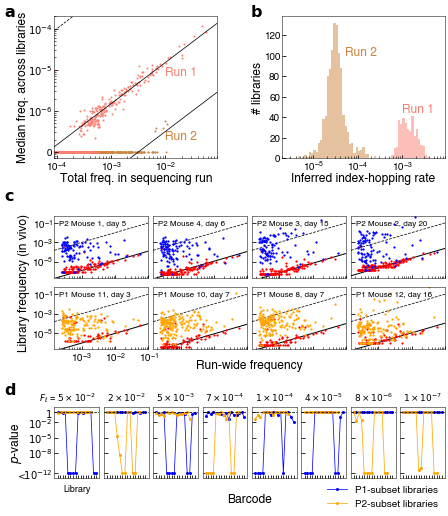

In [4]:
## index-hopping figure
figure = plt.figure(figsize=(7, 8.5))

gs = plt.GridSpec(3, 2, figure=figure, wspace=0.35, hspace=0.5, height_ratios=[1.6,1.5,0.8])
global_ax = figure.add_subplot(gs[:, :])
global_ax.text(-.13, 1, '$\\bf{a}$', fontsize=16, transform=global_ax.transAxes)
global_ax.text(0.5, 1, '$\\bf{b}$', fontsize=16, transform=global_ax.transAxes)
global_ax.text(-.13, 0.6, '$\\bf{c}$', fontsize=16, transform=global_ax.transAxes)
global_ax.text(-.13, 0.18, '$\\bf{d}$', fontsize=16, transform=global_ax.transAxes)
plot_utils.turn_off_ax(global_ax)

# summary ax
summary_gs = gs[0, :].subgridspec(1, 2, wspace=0.4, hspace=0.15)
median_ax = figure.add_subplot(summary_gs[0])
for seqrun_array, seqrun_depths, rescale, color in [(og_seq_array, og_seq_depths,10**-4.5, 'peru'), 
                                             (reseq_array, reseq_depths,  1.5*10**(-3), 'salmon')]:
    seqrun_bc_tot_freqs = seqrun_array.sum(axis=0) / seqrun_depths[:, 0].sum()
    sorting = np.argsort(seqrun_bc_tot_freqs)[::-1]
    lib_freqs = np.einsum('ij,i->ij', seqrun_array, seqrun_depths[:, 0]**-1.)
    median_freqs = np.percentile(lib_freqs, 50, axis=0)[sorting]
    median_freqs[median_freqs == 0] = 1e-7
    median_ax.scatter(seqrun_bc_tot_freqs[sorting[:1000]], median_freqs[:1000], s=1, color=color)
    median_ax.axline( (10**-3, rescale*10**-3), (10**-2, rescale*10**-2), color='black')

plot_utils.plot_diagonal(median_ax)
median_ax.set_yscale('log')
median_ax.set_xscale('log')
median_ax.set_xlim(9*10**-5, 9*10**-2)
median_ax.set_ylim(7*10**-8, 2*10**-4)
median_ax.set_yticks([10**-7, 10**-6, 10**-5, 10**-4])
median_ax.set_yticklabels([r'0', r'$10^{-6}$', r'$10^{-5}$', r'$10^{-4}$'])
median_ax.set_ylabel('Median freq. across libraries', fontsize=12, labelpad=-1)
median_ax.set_xlabel('Total freq. in sequencing run', fontsize=12, labelpad=0)
median_ax.text(10**-2, 7*10**-6, 'Run 1', color='salmon', fontsize=12)
median_ax.text(10**-2, 2*10**-7, 'Run 2', color='peru', fontsize=12)
for spine in median_ax.spines.values():
    spine.set_linewidth(0.5)



lib_hopping_ax = figure.add_subplot(summary_gs[1])
og_seq_hopping = np.array(list(barcode_hopping_rates['vivo']) + list(barcode_hopping_rates['vitro']))
# density, bins = np.histogram(og_seq_hopping[og_seq_depths[:,0] > 1e4], bins=np.logspace(-7, 0, 141))
lib_hopping_ax.hist(og_seq_hopping[og_seq_depths[:,0] > 1e4], bins=np.logspace(-7, 0, 141), alpha=0.5, color='peru')
lib_hopping_ax.text(5*10**-5, 100, 'Run 2', color='peru', fontsize=12)
# density, bins = np.histogram(barcode_hopping_rates['reseq'][reseq_depths[:,0] > 1e4], bins=np.logspace(-7, 0, 141))
lib_hopping_ax.hist(barcode_hopping_rates['reseq'][reseq_depths[:,0] > 1e4], bins=np.logspace(-7, 0, 141), alpha=0.5, color='salmon')
lib_hopping_ax.text(10**-3, 45, 'Run 1', color='salmon', fontsize=12)
lib_hopping_ax.set_xscale('log')
lib_hopping_ax.set_xlim(2*10**-6, 9*10**-3)
lib_hopping_ax.set_ylabel('# libraries', fontsize=12, labelpad=0)
lib_hopping_ax.set_xlabel('Inferred index-hopping rate', fontsize=12, labelpad=0)
for spine in lib_hopping_ax.spines.values():
    spine.set_linewidth(0.5)




## barcode ax
barcode_gs = gs[2, :].subgridspec(1, 8, wspace=0.1, hspace=0.15)
outer_ax = figure.add_subplot(barcode_gs[:, :])
# outer_ax.set_xlabel('Sequencing replicate                                              ', fontsize=12, labelpad=10)
outer_ax.set_xlabel('Barcode', fontsize=12, labelpad=15)
outer_ax.set_ylabel(r'$p$-value', fontsize=12, labelpad=30)
plot_utils.turn_off_ax(outer_ax)


example_barcodes = np.arange(0, 8)
# example_barcodes = []
example_barcodes = np.logspace(0, np.log10(60000), 8, dtype=int)
for z, bc_index in enumerate(example_barcodes):
    ax = figure.add_subplot(barcode_gs[z])

    bc_tot_freq = unsorted_reseq_freqs[sorting][bc_index]
    P1_pvals = P1_uncombined_sorted[:, bc_index]
    P2_pvals = P2_uncombined_sorted[:, bc_index]
    
    ax.plot( P1_pvals, marker='o', label='P1-subset libraries', markersize=2, lw=0.75, color='blue')
    ax.plot( P2_pvals, marker='o', label='P2-subset libraries', markersize=2, lw=0.75, color='orange')
    ax.set_yscale('log')
    ax.set_ylim( 10**-13, 10)
    ax.set_yticks( [10**-12, 10**-8, 10**-5, 10**-2, 1])
    ax.set_xlim(-1.25, 16.25)
    ax.set_yticklabels([r'<$10^{{-12}}$',r'$10^{{-8}}$', r'$10^{{-5}}$', r'$10^{{-2}}$', r'$1$'])
    # ax.set_title(f'Barcode {bc_index}: f_tot = {bc_tot_freq:.2e}', fontsize=10)
    if z == 0:
        # situate legend at bottom, below plot
        ax.set_title(r'$F_\ell$ = '+ f'${plot_utils.as_si(bc_tot_freq, 0)}$        ', fontsize=9)
        ax.set_xlabel('Library', fontsize=9)
    if z != 0:
        ax.set_yticklabels([])
        ax.set_title(f'${plot_utils.as_si(bc_tot_freq, 0)}$', fontsize=9)
    if z == 7:
        ax.legend(loc='lower right', bbox_to_anchor=(1.05, -0.55),  fontsize=10, frameon=False)

    # ax.set_xticks([])
    ax.set_xticks(range(0, 16))
    ax.set_xticklabels([])
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
    ax.axhline(1, color='black', linestyle='dashed')
    

### example libraries
# fig, axs = plt.subplots(2,4, figsize=(8,4.5), gridspec_kw={'wspace':0.05, 'hspace':0.15})
lib_gs = gs[1, :].subgridspec(2, 4, wspace=0.05, hspace=0.15)
outer_ax = figure.add_subplot(lib_gs[:, :])
outer_ax.set_xlabel('Run-wide frequency', fontsize=12, labelpad=10)
outer_ax.set_ylabel('Library frequency (in vivo)', fontsize=12, labelpad=24)
plot_utils.turn_off_ax(outer_ax)

example_libraries = rnd.choice(range(len(reseq_array)), 8, replace=False)
# example_libraries = [22,34, 71, 122, 9, 254,281,296] # representative libraries 
example_libraries = [22,34, 71, 122, 9, 49,47, 97] # representative libraries 

for z, arr_index in enumerate(example_libraries):
    ax = figure.add_subplot(lib_gs[z//4, z%4])


    (expt, pop, day) = col_id_map['reseq'][arr_index]
    est_hopping_rate = barcode_hopping_rates['reseq'][arr_index]
    lib_hopping_data = hopping_inference_data[('reseq', arr_index)]

    # if ('reseq', arr_index) in 
    if expt == 'E1' and type(pop) == int and pop < 6:
        barcode_indices = barcode_pool_assignments['P2'][0]
        inoc = 'P2'
    elif expt == 'E1' and type(pop) == int and pop >= 6:
        barcode_indices = barcode_pool_assignments['P1'][0]
        inoc = 'P1'
    elif expt == 'E2' and type(pop) == int and pop in [1,6,11]:
        barcode_indices = barcode_pool_assignments['S1'][0]
        inoc = "S1"
    elif expt == 'E2' and type(pop) == int and pop in [2,7,12]:
        barcode_indices = barcode_pool_assignments['S2'][0]
        inoc = "S2"
    else:
        continue


    large_indices = lib_hopping_data['included_indices']
    valid_bool = lib_hopping_data['valid_bool']

    run_freqs = lib_hopping_data['run_freqs']
    lib_freqs = lib_hopping_data['lib_freqs']

    in_inoculum = [i in barcode_indices for  i in large_indices]
    not_in_inoculum = [i not in barcode_indices for i in large_indices]

    if z < 4:
        color = 'blue'
    else:
        color = 'orange'
    ax.scatter( run_freqs[not_in_inoculum], lib_freqs[not_in_inoculum], s=1.5, color='red' )
    ax.scatter( run_freqs[in_inoculum], lib_freqs[in_inoculum], s=1.5, color=color)
    ax.axline( (10**-3, 10**-3 * est_hopping_rate), (10**-2, 10**-2 * est_hopping_rate), color='black', lw=1, zorder=0)
    plot_utils.plot_diagonal( ax )
    # ax.set_title(f'{arr_index}, {expt}, {pop}, {day}')
    ax.text(0.05, 0.85, f'{inoc} Mouse {pop}, day {day}', transform=ax.transAxes, fontsize=8)
    ax.set_yscale('log')
    ax.set_xscale('log')
    if z not in [0, 4]:
        ax.set_yticklabels([])
        ax.set_xticklabels([])
    if z not in [4]:
        ax.set_xticklabels([])
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

    ax.set_xlim( 1.5*10**-4, 10**-1)
    ax.set_ylim( 2*10**-7, 0.5)

figure.savefig(f'{figures_dir}/figS1E-H_index_hopping.pdf', bbox_inches='tight', transparent=True, dpi=300)
figure.savefig(f'{figures_dir}/figS1E-H_index_hopping.svg', bbox_inches='tight', transparent=True, dpi=300)


## Fig. S1I: technical-replicate conditional read-count distributions


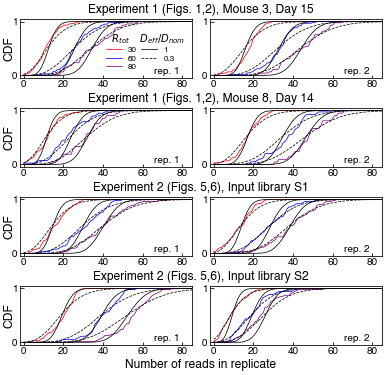

In [5]:
lib_names = [('E1', 3, 15), 
             ('E1', 8, 14), 
             ('E2', 'S1'), 
             ('E2', 'S2')] # each of these libraries have 2 reseq replicates 

figure = plt.figure(figsize=(6.5,6))
gs = figure.add_gridspec(4, 2, hspace=0.5, wspace=0.1)

for row, sample in enumerate(lib_names):
        reseq_indices = [idx for (arr_name, idx) in shared.library_array_map[sample] if arr_name == 'reseq']
        
        row_ax = figure.add_subplot(gs[row, :])
        plot_utils.turn_off_ax(row_ax)
        row_ax.set_ylabel('CDF', fontsize=12)
        if len(sample) == 2: ## in vivo
                row_ax.set_title(f'Experiment 2 (Figs. 5,6), Input library {sample[1]}', fontsize=12)
        else:
                row_ax.set_title(f'Experiment 1 (Figs. 1,2), Mouse {sample[1]}, Day {sample[2]}', fontsize=12)
        if row == 3:
                row_ax.set_xlabel('Number of reads in replicate', fontsize=12, labelpad=14)

        for col, (idx1, idx2) in enumerate([reseq_indices, reseq_indices[::-1]]):
                reads1, reads2 = shared.reseq_array[idx1], shared.reseq_array[idx2]
                depth1, depth2 = shared.reseq_depths[idx1][1], shared.reseq_depths[idx2][1]
                summed_reads = reads1 + reads2

                not_runwide_large_barcodes = np.full(len(summed_reads),True)
                not_runwide_large_barcodes[sorting[:500]] = False
                
                rep_frac = depth2 / (depth1 + depth2)

                
                ax = figure.add_subplot(gs[row, col])

                for tot_read_of_bc, color in zip([30, 60, 80], ['red', 'blue', 'purple']):
                        valid_bool = (summed_reads == tot_read_of_bc) & not_runwide_large_barcodes
                        if (summed_reads == tot_read_of_bc).sum() < 20:
                                continue
                        bins = np.arange(0, 2*tot_read_of_bc)
                        density, bins = np.histogram(reads2[summed_reads == tot_read_of_bc], bins=bins,
                                           density=True)
                        empirical_cdf= np.cumsum(density)
                        ax.plot(bins[:-1], empirical_cdf, color=color, label=f'{tot_read_of_bc}')
                        

                        for alpha, linestyle, label in [(10**10, 'solid', r'1'), (0.3, 'dashed', r'0.3')]:
                                theory_samples = rnd.poisson( rnd.poisson( tot_read_of_bc * rep_frac * alpha, 10**4) / alpha ) 
                                theory_density, bins = np.histogram(theory_samples, bins=bins, density=True)
                                theory_cdf = np.cumsum(theory_density)
                                
                                if tot_read_of_bc != 80:
                                        label = ''
                                ax.plot(bins[:-1], theory_cdf, linestyle=linestyle, color='black', label=label)
                       
                        ax.set_xlim(-2, 85)
                        ax.set_yticks([0, 1])
                        if col == 0 and row == 0:
                               # legend with label vertical spacing =2
                                ax.legend(ncol=2, title='      $R_{tot}$    $D_{eff}/D_{nom}$', 
                                        fontsize=8, title_fontsize=10, columnspacing=0.5, labelspacing=0.1, frameon=False, )

                               
                ax.text(0.78, 0.07, f'rep. {col+1}', transform=ax.transAxes)

figure.savefig(f'{figures_dir}/figS1I_reseq_run_replicate_libraries_noise.svg', format='svg', transparent=True, bbox_inches='tight')
figure.savefig(f'{figures_dir}/figS1I_reseq_run_replicate_libraries_noise.pdf', transparent=True, bbox_inches='tight')


## Fig. S1J: effective detection limits


E2 5 50


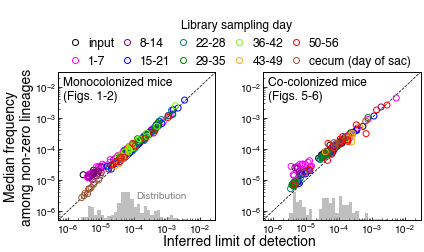

In [6]:

fig = plt.figure(figsize=(6.5,4))
gs = plt.GridSpec(2, 2, height_ratios=(1,3), width_ratios=[1,1], wspace=0.3, figure=fig)
outer_ax = fig.add_subplot(gs[1, :])
plot_utils.turn_off_ax(outer_ax)
outer_ax.set_xlabel('Inferred limit of detection', fontsize=14, labelpad=14)
outer_ax.set_ylabel('Median frequency\namong non-zero lineages', fontsize=14, labelpad=24)


cmap = {day+7*week: color for day in range(1,8) for week, color in enumerate(
    ['fuchsia', 'purple', 'blue', 'teal', 'green', 'lawngreen', 'orange', 'red'])}
cmap['cecum'] = 'sienna'
cmap[0] = 'black'
legend_markers = [plt.Line2D([0], [0], marker='o', linestyle='none', mec=color, mfc='none') \
                  for week, color in enumerate(['black', 'fuchsia', 'purple', 'blue', 'teal', 'green', 'lawngreen', 'orange', 'red', 'sienna'])]
legend_ax = fig.add_subplot(gs[0, :])
plot_utils.turn_off_ax(legend_ax)
legend_ax.legend(legend_markers, ['input']+[f'{1+7*week}-{7*(week+1)}' for week in range(0,8)] + ['cecum (day of sac)'], title='Library sampling day', title_fontsize=12,
                  loc=(0.0, -0.4), ncol=5, fontsize=12, frameon=False, columnspacing=0.05, handletextpad=0.1)


E1_ax = fig.add_subplot(gs[1, 0])
E2_ax = fig.add_subplot(gs[1,1])

E1_ax.text(0.03, 0.97, 'Monocolonized mice\n(Figs. 1-2)', transform=E1_ax.transAxes, va='top', fontsize=12)
E2_ax.text(0.03, 0.97, 'Co-colonized mice\n(Figs. 5-6)', transform=E2_ax.transAxes, va='top', fontsize=12)

P1_index, P2_index = 0, 1
x, y = [], []
w, z = [], []

frac_low_diversity = []
for lib, reps in shared.library_array_map.items():
    expt = lib[0]
    mouse = lib[1]

    if expt not in ['E1', 'E2']: #vivo libraries first
        continue
    if len(lib) == 3 and (lib[2] == 0 or lib[2]=='smallint' or (expt == 'E2' and lib[1] > 10 and lib[2] == 14)): #skip
        continue

    if len(lib) == 2:
        day = 0
    else:
        day = lib[2]
    
    
    for (arr_name, index) in reps:
        if arr_name == 'reseq':
            continue

        reads, (D_nom, D_det) = shared.barcode_arrays[arr_name][0][index], shared.barcode_arrays[arr_name][1][index]
            
        freq_array = shared.calc_freqs(reads, D_nom)
        median_nonzero_freq_in_lib = np.median(freq_array[freq_array > 0])
        if 1/D_det < 1e-6 and expt == 'E2':
            print(lib, median_nonzero_freq_in_lib, 1/D_det)

        if expt == 'E1':
            E1_ax.scatter(1/D_det, median_nonzero_freq_in_lib, marker='o', facecolors='none', edgecolors=cmap[day])
            x.append(1/D_det)

        if expt == 'E2' and mouse not in [5, 10, 15]: #exclude low-diversity mice for clarity
            E2_ax.scatter(1/D_det, median_nonzero_freq_in_lib, marker='o', facecolors='none', edgecolors=cmap[day] )
            y.append(1/D_det)

        if median_nonzero_freq_in_lib < 0.01 * 1/D_det:
            print(expt, mouse, day)



E1_ax_dist = E1_ax.twinx()
E1_ax_dist.hist(x, bins=np.logspace(-6, -2, 41), color='grey', alpha=0.5, density=False, histtype='stepfilled', lw=0)
E2_ax_dist = E2_ax.twinx()
E2_ax_dist.hist(y, bins=np.logspace(-6, -2, 41), color='grey', alpha=0.5, density=False, histtype='stepfilled', lw=0)
for dist_ax in [E1_ax_dist, E2_ax_dist]:
    dist_ax.set_yticks([])
    dist_ax.set_ylim(dist_ax.get_ylim()[0], dist_ax.get_ylim()[1]*5)
E1_ax_dist.text(0.5, 0.15, "Distribution", transform=E1_ax_dist.transAxes, ha='left', color='grey', fontsize=10)

for i, ax in enumerate([E1_ax, E2_ax]):
    plot_utils.plot_diagonal(ax)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(0.5*10**-6, 3*10**-2)
    ax.set_ylim(0.5*10**-6, 3*10**-2)
    ax.set_xticks([10**-6, 10**-5, 10**-4, 10**-3, 10**-2])

fig.savefig(f'{figures_dir}/figS1J_umi_dereplication.svg', format='svg', transparent=True, bbox_inches='tight')
fig.savefig(f'{figures_dir}/figS1J_umi_dereplication.pdf', transparent=True, bbox_inches='tight')
